In [2]:
import pandas as pd
import datetime as dtm
from chinese_calendar import is_holiday
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import distributions
import powerlaw
import numpy as np
import seaborn as sns
import h3
from MoranI import moranI
from scipy.stats import kstest, gaussian_kde
import matplotlib.ticker as ticker

In [3]:
res = 9
work_path = os.path.abspath(os.getcwd()+os.path.sep+"..")
data_path = os.path.join(work_path,'Results','Beijing','RES=%s' % res)

all_strength = pd.read_csv(os.path.join(data_path,'all_strength.csv'))
all_strength.date = all_strength['date'].apply(lambda x: dtm.datetime.strptime(str(x),"%Y%m%d"))

In [ ]:
sele_strength = all_strength
day_fit = []
for dd in sele_strength['date'].value_counts().to_frame().index:
    day_strength = sele_strength.loc[sele_strength['date']==dd]
    s = day_strength['strength_values'].value_counts().to_frame().reset_index(drop=False).sort_values('index')
    xdata = s['index'].values
    ydata = s['strength_values'].values
    ydata = ydata/sum(ydata)
    def func(x,alpha,a):
        pl = np.power(x,-alpha)
        return pl*a
    def func2(x,alpha,beta,a):
        pl = np.power(x,-alpha)
        ex = np.exp(-x/beta)
        return pl*ex*a
    popt_l, pcov_l = curve_fit(func, xdata, ydata,p0=[0.4,0.008], maxfev = 5108000)
    popt_t, pcov_t = curve_fit(func2, xdata, ydata,p0=[0.3,100,0.01], maxfev = 5108000)
    ks_l = kstest(np.cumsum(ydata),np.cumsum(func(xdata, *popt_l)))
    ks_t = kstest(np.cumsum(ydata),np.cumsum(func2(xdata, *popt_t)))
    day_fit.append([dd,popt_l[0],ks_l[0],ks_l[1],popt_t[0],popt_t[1],ks_t[0],ks_t[1]])

pd.DataFrame(day_fit).to_csv(os.path.join(data_path,'BJfit.csv'))

In [11]:
pd.DataFrame(day_fit)

,0,1,2,3,4,5,6,7
0,2019-12-12,0.499992,0.202216,4.645801e-52,0.445241,2830.007249,0.111842,3.819463e-16
1,2019-12-09,0.509880,0.189667,7.749368e-45,0.461193,3150.923875,0.091649,9.538858e-11
2,2019-12-13,0.500257,0.182197,4.103165e-42,0.453603,3491.351851,0.089360,2.068382e-10
3,2019-12-06,0.505711,0.175866,8.350207e-40,0.461252,3640.291889,0.086733,5.764642e-10
4,2019-12-10,0.500240,0.200070,3.424366e-50,0.444659,2768.278866,0.110056,2.055517e-15
5,2019-12-11,0.503262,0.203863,3.083037e-51,0.449284,2761.668510,0.107296,1.982261e-14
6,2019-12-05,0.492484,0.202984,2.395912e-52,0.428701,2412.162984,0.138446,1.728526e-24
7,2019-12-04,0.495574,0.172091,9.485183e-38,0.447624,3515.274236,0.087258,5.506398e-10
8,2019-12-07,0.506578,0.208996,1.060460e-49,0.436089,1968.657945,0.143854,1.113528e-23
9,2019-12-08,0.510091,0.221671,1.905049e-52,0.430584,1594.602422,0.168321,2.588921e-30


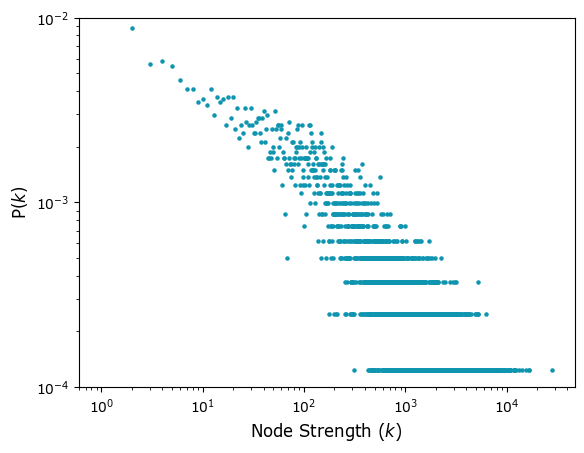

In [4]:
d = 2
for day in all_strength.date.unique():
    daily = all_strength[all_strength['date']==day]
    s = daily['strength_values'].value_counts().to_frame().reset_index(drop=False).sort_values('index')
    xdata = s['index'].values
    ydata = s['strength_values'].values
    ydata = ydata
    ydata = ydata/sum(ydata)

    plt.clf()

    plt.rcParams['font.sans-serif'] = ['Verdana']
    plt.rcParams['savefig.dpi'] = 600
    plt.rcParams['figure.figsize'] = (5.0, 4.5)
    plt.scatter(xdata, ydata, s= 5, color='#0f95b0', label='Data')
    plt.xlabel('Node Strength ($k$)',fontsize=12)
    plt.ylabel('P$(k)$',fontsize=12)
    plt.xscale('log')
    plt.yscale('log')
    plt.ylim((10e-5,10e-3))
#    plt.title('Lianyungang',loc='left')
#    plt.show()
    figname = 'BJP'+str(d)+'.png'
    plt.savefig(os.path.join(data_path,figname))
    d = d + 1

In [3]:
daily = all_strength[all_strength['date']=='2019-12-4']
s = daily['strength_values'].value_counts().to_frame().reset_index(drop=False).sort_values('index')
xdata = s['index'].values
ydata = s['strength_values'].values
ydata = ydata/sum(ydata)

# xdata = daily['strength_values'].sort_values(ascending=True)
# kde = gaussian_kde(xdata,bw_method=0.001)
# pdf = kde(xdata)
# ydata = pdf#/np.sum(pdf)

def func(x,alpha,a):
    pl = np.power(x,-alpha)
    return pl*a
def func2(x,alpha,beta,a):
    pl = np.power(x,-alpha)
    ex = np.exp(-x/beta)
    return pl*ex*a
popt_l, pcov_l = curve_fit(func, xdata, ydata, p0=[0.4,0.008],maxfev = 51008000)
popt_t, pcov_t = curve_fit(func2, xdata, ydata, p0=[0.3,100,0.01], maxfev = 51080000)
print(popt_l)
print(popt_t)


[0.49557361 0.01052724]
[4.47623719e-01 3.51527424e+03 9.62078786e-03]


In [4]:

from sklearn.metrics import r2_score
 
# y_true为实际观测值，y_pred为模型预测值
r2_l = r2_score(ydata, func(xdata, *popt_l))
r2_t = r2_score(ydata, func2(xdata, *popt_t))
print("ppl r2: ", r2_l)
print("etpl r2: ", r2_t)

ppl r2:  0.8409837640845846
etpl r2:  0.8539577657810021


In [5]:
print(r2_score(np.cumsum(ydata),np.cumsum(func(xdata, *popt_l))))
print(r2_score(np.cumsum(ydata),np.cumsum(func2(xdata, *popt_t))))

0.9555184599139634
0.985732011177665


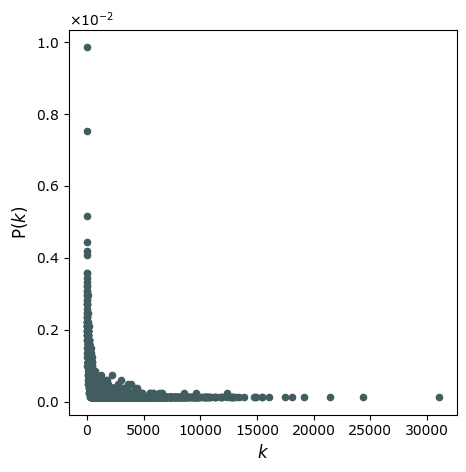

In [6]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (5.0, 5)
plt.scatter(xdata, ydata, s= 20, color='#425d5f', label='Data')
plt.xlabel('$k$',fontsize=12)
plt.ylabel('P$(k)$',fontsize=12)
ax = plt.gca()
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2,-2))
ax.yaxis.set_major_formatter(formatter)
#plt.title('Beijing',loc='left')
# plt.show()
plt.savefig(r"D:\Papers\202209_demand_analyse\pic\bus\BJ1.tif")

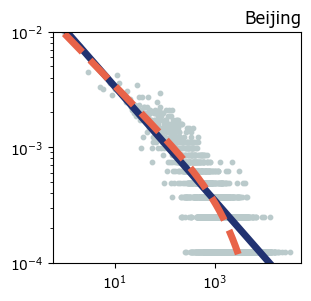

In [8]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (3.2, 3)
plt.scatter(xdata, ydata, s = 10, color='#bacacb')
plt.plot(xdata, func(xdata, *popt_l), '#213271', lw=5,)
plt.plot(xdata, func2(xdata, *popt_t), '#e86349', lw=5, linestyle = "--")
plt.xscale('log')
plt.yscale('log')
plt.ylim((10e-5,10e-3))
plt.title('Beijing',loc='Right')
# plt.show()
plt.savefig(r"D:\Papers\202209_demand_analyse\pic\bus\BJ2.tif")

In [38]:
from scipy.stats import kstest

print(kstest(np.cumsum(ydata),np.cumsum(func(xdata, *popt_l))))
print(kstest(np.cumsum(ydata),np.cumsum(func2(xdata, *popt_t))))

KstestResult(statistic=0.17209141274238227, pvalue=9.485182648750198e-38, statistic_location=0.9998767865943432, statistic_sign=1)
KstestResult(statistic=0.08725761772853186, pvalue=5.506397731210425e-10, statistic_location=0.8718580581567158, statistic_sign=1)


In [49]:
fit = powerlaw.Fit(daily['strength_values'], xmin=1, discrete=True)

# 比较幂律分布和指数截断幂律分布
R, p = fit.distribution_compare('power_law', 'truncated_power_law')
print("似然比统计量:", R)
print("p值:", p)

Assuming nested distributions


似然比统计量: -4298.689250674784
p值: 0.0


In [58]:
from scipy.stats import chi2
log_likelihood_powerlaw = len(xdata) * np.log(popt_l[1]) - popt_l[0] * np.sum(np.log(xdata))
log_likelihood_truncated = len(xdata) * np.log(popt_t[2]) - popt_t[0] * np.sum(np.log(xdata)) - np.sum(xdata) / popt_t[1]
LR_stat = 2 * (-log_likelihood_powerlaw + log_likelihood_truncated)
df = len(popt_t)-len(popt_l)
p_value = chi2.sf(LR_stat, df)
print("似然比统计量:", LR_stat)
print("p值:", p_value)

似然比统计量: -2465.1898517739464
p值: 1.0


In [12]:
c1 = len(np.where(np.cumsum(ydata)<0.50)[0])
c2 = len(np.where(np.cumsum(ydata)<0.55)[0])
c3 = len(np.where(np.cumsum(ydata)<0.60)[0])
c4 = len(np.where(np.cumsum(ydata)<0.65)[0])
c5 = len(np.where(np.cumsum(ydata)<0.70)[0])
c6 = len(np.where(np.cumsum(ydata)<0.75)[0])
c7 = len(np.where(np.cumsum(ydata)<0.80)[0])
c8 = len(np.where(np.cumsum(ydata)<0.85)[0])
c9 = len(np.where(np.cumsum(ydata)<0.90)[0])
c0 = len(np.where(np.cumsum(ydata)<0.95)[0])

vline = [c1,c2,c3,c4,c5,c6,c7,c8,c9,c0,len(ydata)]
print(c1,c2,c3,c4,c5,c6,c7,c8,c9,c0,len(ydata))

465 576 715 875 1055 1276 1513 1793 2106 2458 2839


In [13]:
def color_vector(start_color, end_color, num_steps):
    # 计算每一阶的颜色
    colors = []
    for i in range(num_steps):
        r = int(start_color[0] - (start_color[0] - end_color[0]) / (num_steps - 1) * i)
        g = int(start_color[1] - (start_color[1] - end_color[1]) / (num_steps - 1) * i)
        b = int(start_color[2] - (start_color[2] - end_color[2]) / (num_steps - 1) * i)
        color = (r, g, b)
        colors.append(color)
    
    # 输出每一阶颜色的 16 进制表示
    hex_colors = []
    for color in colors:
        hex_color = "#{:02x}{:02x}{:02x}".format(color[0], color[1], color[2])
        hex_colors.append(hex_color)
    
    # 返回颜色向量
    return hex_colors

In [14]:
# def puring_fit(strength,c):
#     strength = strength.sort_values(by='index', ascending=True).reset_index(drop=True)
#     strength = strength.iloc[:c]
    
#     ydata = strength['strength_values'].values
#     xdata = strength['index'].values
#     ydata = ydata/sum(ydata)

#     return xdata, ydata

def puring_fit(strength,c):
    strength = strength.sort_values(by='index', ascending=True).reset_index(drop=True)
    
    ydata = strength['strength_values'].values
    xdata = strength['index'].values
    ydata = ydata/sum(ydata)

    xdata = xdata[:c]
    ydata = ydata[:c]


    return xdata, ydata

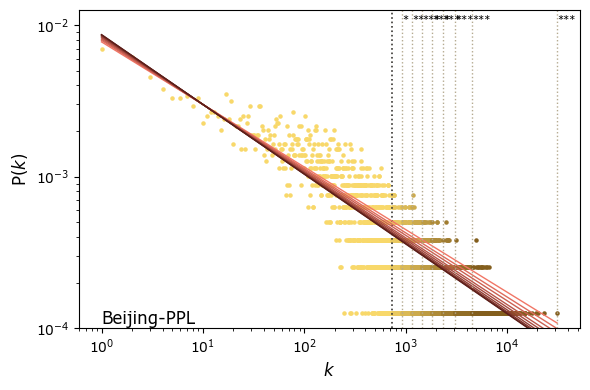

In [21]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (6, 4)

xinpos = 10**-2

vline = [c3,c4,c5,c6,c7,c8,c9,c0,len(ydata)]

lyg_dot_clr = color_vector((248,216,106), (131,94,29), len(vline))
lyg_lne_clr = color_vector((241,118,102), (92,30,25), len(vline))

ppl = pd.DataFrame([])

for posi in range(len(vline)):
    c = vline[posi]
    x_data, y_data = puring_fit(s,c)
    popt, pcov = curve_fit(func, x_data, y_data, p0=[0.4,0.008], maxfev = 5108000)
    y_fit = func(xdata, *popt)
    ks = kstest(np.cumsum(y_data[:c]),np.cumsum(y_fit[:c]))
    # ks = kstest(np.cumsum(ydata),np.cumsum(y_fit[:c]))

    pl = pd.DataFrame({
        'puring': [posi],
        'et_alpha': [popt[0]],
        'et_d': [ks[0]],
        'et_pvalue': [ks[1]]
    })

    ppl = pd.concat([ppl,pl])

    #虚线
    if ks[1] < 0.05:
        plt.vlines(x=x_data.max(), ymin=10e-5,ymax=10e-1, lw=1, ls=":",color="#b5aa90")
        if ks[1] < 0.001:
            plt.text(x_data.max(),xinpos,"***", ha='left', va='bottom',fontsize=7)
        elif (ks[1] >= 0.001)&(ks[1] < 0.01):
            plt.text(x_data.max(),xinpos,"**", ha='left', va='bottom',fontsize=7)
        else:
            plt.text(x_data.max(),xinpos,"*", ha='left', va='bottom',fontsize=7)
    else:
        plt.vlines(x=x_data.max(), ymin=10e-5,ymax=10e-2, lw=1.2, ls=":",color="#393733")

    #点
    if posi == 0:
        plt.scatter(xdata[:c], ydata[:c], s= 5, color=lyg_dot_clr[posi])
    else:
        plt.scatter(xdata[vline[posi-1]:vline[posi]], ydata[vline[posi-1]:vline[posi]], s= 5, color=lyg_dot_clr[posi])

    #线
    plt.plot(xdata, y_fit, lw=1, color=lyg_lne_clr[posi])


plt.text(xdata.min(),10e-5,"Beijing-PPL", ha='left', va='bottom', fontsize=12)

# plt.title('Beijing',loc='right')
plt.xscale('log')
plt.yscale('log')
plt.ylim((10e-5,10**-1.9))
plt.xlabel('$k$',fontsize=12)
plt.ylabel('P$(k)$',fontsize=12)
# plt.legend(loc='upper right')
plt.tight_layout()
# plt.show()
plt.savefig(r"D:\Papers\202209_demand_analyse\pic\bus\BJppl.tif")

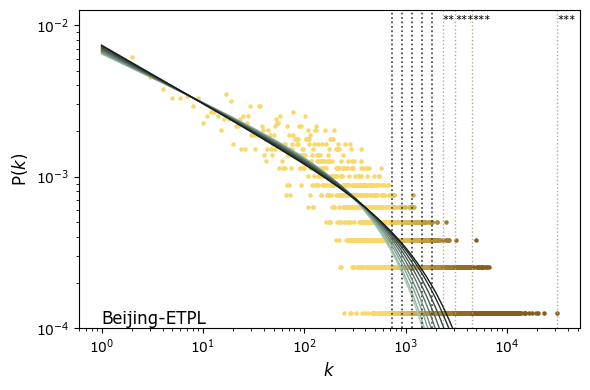

In [27]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (6, 4)

vline = [c3,c4,c5,c6,c7,c8,c9,c0,len(ydata)]

lyg_dot_clr = color_vector((248,216,106), (131,94,29), len(vline))
lyg_lne_clr = color_vector((164,202,182), (20,30,27), len(vline))

etpl = pd.DataFrame([])

for posi in range(len(vline)):
    c = vline[posi]
    x_data, y_data = puring_fit(s,c)
    poptt, pcovv = curve_fit(func2, x_data, y_data, p0=[0.3,100,0.01], maxfev = 5108000)
    y_fit = func2(xdata, *poptt)
    ks = kstest(np.cumsum(y_data[:c]),np.cumsum(y_fit[:c]))
    # ks = kstest(np.cumsum(ydata),np.cumsum(y_fit[:c]))

    et = pd.DataFrame({
        'puring': [posi],
        'et_alpha': [poptt[0]],
        'et_lambda': [poptt[1]],
        'et_d': [ks[0]],
        'et_pvalue': [ks[1]]
    })

    etpl = pd.concat([etpl,et])

    #虚线
    if ks[1] < 0.05:
        plt.vlines(x=x_data.max(), ymin=10e-5,ymax=10e-1, lw=1, ls=":",color="#b5aa90")
        if ks[1] < 0.001:
            plt.text(x_data.max(),xinpos,"***", ha='left', va='bottom',fontsize=7)
        elif (ks[1] >= 0.001)&(ks[1] < 0.01):
            plt.text(x_data.max(),xinpos,"**", ha='left', va='bottom',fontsize=7)
        else:
            plt.text(x_data.max(),xinpos,"*", ha='left', va='bottom',fontsize=7)
    else:
        plt.vlines(x=x_data.max(), ymin=10e-5,ymax=10e-2, lw=1.2, ls=":",color="#393733")

    #点
    if posi == 0:
        plt.scatter(xdata[:vline[posi]], ydata[:vline[posi]], s= 5, color=lyg_dot_clr[posi])
    else:
        plt.scatter(xdata[vline[posi-1]:vline[posi]], ydata[vline[posi-1]:vline[posi]], s= 5, color=lyg_dot_clr[posi])

    #线
    plt.plot(xdata, y_fit, lw=1, color=lyg_lne_clr[posi])

plt.text(xdata.min(),10e-5,"Beijing-ETPL", ha='left', va='bottom', fontsize=12)

# plt.title('Beijing',loc='right')
plt.xscale('log')
plt.yscale('log')
plt.ylim((10e-5,10**-1.9))
plt.xlabel('$k$',fontsize=12)
plt.ylabel('P$(k)$',fontsize=12)
# plt.legend(loc='upper right')
plt.tight_layout()
# plt.show()
plt.savefig(r"D:\Papers\202209_demand_analyse\pic\bus\BJetpl.tif")


In [24]:
ppl

,puring,et_alpha,et_d,et_pvalue
0,0,0.412860,0.069930,6.058012e-02
0,1,0.423389,0.075429,1.374585e-02
0,2,0.431534,0.077725,3.400895e-03
0,3,0.439943,0.091693,4.336871e-05
0,4,0.445966,0.105089,1.079734e-07
0,5,0.451692,0.122142,4.552829e-12
0,6,0.456102,0.138651,4.629393e-18
0,7,0.459317,0.157038,7.441190e-27
0,8,0.460411,0.178232,8.531469e-40


In [28]:
etpl

,puring,et_alpha,et_lambda,et_d,et_pvalue
0,0,0.316003,787.244088,0.012587,1.000000e+00
0,1,0.320097,838.804747,0.016000,9.998796e-01
0,2,0.327881,941.108477,0.028436,7.874512e-01
0,3,0.335542,1054.313674,0.038401,3.036852e-01
0,4,0.345160,1218.679656,0.045605,8.597399e-02
0,5,0.354700,1415.317070,0.058561,4.263916e-03
0,6,0.365038,1677.125913,0.065527,2.354719e-04
0,7,0.375754,2021.245613,0.076078,1.311534e-06
0,8,0.383913,2348.235752,0.132793,3.150875e-22


In [31]:
popt1, pcov1 = curve_fit(func, xdata[:c1], ydata[:c1], p0=[0.4,0.008], maxfev = 5108000)
popt2, pcov2 = curve_fit(func, xdata[:c2], ydata[:c2], p0=[0.4,0.008], maxfev = 5180000)
popt3, pcov3 = curve_fit(func, xdata[:c3], ydata[:c3], p0=[0.4,0.008], maxfev = 5108000)
popt4, pcov4 = curve_fit(func, xdata[:c4], ydata[:c4], p0=[0.4,0.008], maxfev = 5108000)
popt5, pcov5 = curve_fit(func, xdata[:c5], ydata[:c5], p0=[0.4,0.008], maxfev = 5108000)
popt6, pcov6 = curve_fit(func, xdata[:c5], ydata[:c5], p0=[0.4,0.008], maxfev = 5108000)
popt6, pcov6 = curve_fit(func, xdata[:c6], ydata[:c6], p0=[0.4,0.008], maxfev = 5108000)
popt7, pcov7 = curve_fit(func, xdata[:c7], ydata[:c7], p0=[0.4,0.008], maxfev = 5108000)
popt8, pcov8 = curve_fit(func, xdata[:c8], ydata[:c8], p0=[0.4,0.008], maxfev = 5108000)
popt9, pcov9 = curve_fit(func, xdata[:c9], ydata[:c9], p0=[0.4,0.008], maxfev = 5108000)
popt0, pcov0 = curve_fit(func, xdata[:c0], ydata[:c0], p0=[0.4,0.008], maxfev = 5108000)
np.vstack((popt_l,popt0,popt9,popt8,popt7,popt6,popt5,popt4,popt3))

array([[0.49557361, 0.01052724],
       [0.49521453, 0.01051876],
       [0.49357282, 0.01048002],
       [0.49060482, 0.01041262],
       [0.4865605 , 0.01032355],
       [0.48228762, 0.01023196],
       [0.47638289, 0.01010872],
       [0.46792168, 0.00993648],
       [0.45996377, 0.00977852]])

### 不要了

In [32]:

popt11, pcov11 = curve_fit(func2, xdata[:c1], ydata[:c1], p0=[0.3,60,0.01], maxfev = 5108000)
popt22, pcov22 = curve_fit(func2, xdata[:c2], ydata[:c2], p0=[0.3,60,0.01], maxfev = 5180000)
popt33, pcov33 = curve_fit(func2, xdata[:c3], ydata[:c3], p0=[0.3,60,0.01], maxfev = 5108000)
popt44, pcov44 = curve_fit(func2, xdata[:c4], ydata[:c4], p0=[0.3,60,0.01], maxfev = 5108000)
popt55, pcov55 = curve_fit(func2, xdata[:c5], ydata[:c5], p0=[0.3,60,0.01], maxfev = 5108000)
popt66, pcov66 = curve_fit(func2, xdata[:c6], ydata[:c6], p0=[0.3,60,0.01], maxfev = 5108000)
popt77, pcov77 = curve_fit(func2, xdata[:c7], ydata[:c7], p0=[0.3,60,0.01], maxfev = 5108000)
popt88, pcov88 = curve_fit(func2, xdata[:c8], ydata[:c8], p0=[0.3,60,0.01], maxfev = 5108000)
popt99, pcov99 = curve_fit(func2, xdata[:c9], ydata[:c9], p0=[0.3,60,0.01], maxfev = 5108000)
popt00, pcov00 = curve_fit(func2, xdata[:c0], ydata[:c0], p0=[0.3,60,0.01], maxfev = 5108000)
np.vstack((popt_t,popt00,popt99,popt88,popt77,popt66,popt55,popt44,popt33))

array([[4.47625208e-01, 3.51542542e+03, 9.62081293e-03],
       [4.38485862e-01, 2.74079868e+03, 9.46349462e-03],
       [4.28836686e-01, 2.16051456e+03, 9.30330036e-03],
       [4.20413364e-01, 1.78452733e+03, 9.16803355e-03],
       [4.12868283e-01, 1.51690517e+03, 9.05086159e-03],
       [4.05492047e-01, 1.30177155e+03, 8.94015023e-03],
       [3.99649920e-01, 1.15547943e+03, 8.85559069e-03],
       [3.97093650e-01, 1.09548694e+03, 8.81988460e-03],
       [3.95095298e-01, 1.04695949e+03, 8.79327050e-03]])

In [27]:
kstest(np.cumsum(ydata[:c3]),np.cumsum(func(xdata[:c3], *popt3)))

KstestResult(statistic=0.056338028169014086, pvalue=0.2099002527660401, statistic_location=0.350774877117701, statistic_sign=-1)

In [33]:
print(kstest(np.cumsum(ydata[:c3]),np.cumsum(func(xdata[:c3], *popt3))))
print(kstest(np.cumsum(ydata[:c4]),np.cumsum(func(xdata[:c4], *popt4))))
print(kstest(np.cumsum(ydata[:c5]),np.cumsum(func(xdata[:c5], *popt5))))
print(kstest(np.cumsum(ydata[:c6]),np.cumsum(func(xdata[:c6], *popt6))))
print(kstest(np.cumsum(ydata[:c7]),np.cumsum(func(xdata[:c7], *popt7))))
print(kstest(np.cumsum(ydata[:c8]),np.cumsum(func(xdata[:c8], *popt8))))
print(kstest(np.cumsum(ydata[:c9]),np.cumsum(func(xdata[:c9], *popt9))))
print(kstest(np.cumsum(ydata[:c0]),np.cumsum(func(xdata[:c0], *popt0))))
print(kstest(np.cumsum(ydata),np.cumsum(func(xdata, *popt_l))))

KstestResult(statistic=0.056338028169014086, pvalue=0.2099002527660401, statistic_location=0.350774877117701, statistic_sign=-1)
KstestResult(statistic=0.06414662084765177, pvalue=0.05505125728786239, statistic_location=0.47227263463592783, statistic_sign=-1)
KstestResult(statistic=0.07977736549165121, pvalue=0.002087452162199612, statistic_location=0.6987432232626902, statistic_sign=1)
KstestResult(statistic=0.09531129900076864, pvalue=1.4536448505232088e-05, statistic_location=0.7499999999999983, statistic_sign=1)
KstestResult(statistic=0.10823071937783539, pvalue=2.7448720701490684e-08, statistic_location=0.7992853622474086, statistic_sign=1)
KstestResult(statistic=0.12459016393442623, pvalue=8.619831489587367e-13, statistic_location=0.8499260719566205, statistic_sign=1)
KstestResult(statistic=0.13959981386691483, pvalue=1.1416505022515475e-18, statistic_location=0.8990882207984076, statistic_sign=1)
KstestResult(statistic=0.15384615384615385, pvalue=3.5258858992765645e-26, statisti

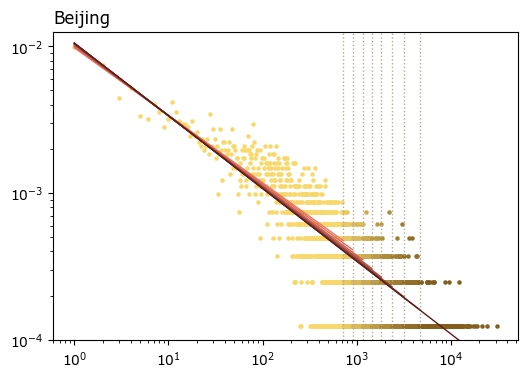

In [38]:

plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (6, 4)

lyg_dot_clr = color_vector((248,216,106), (131,94,29), 9)
lyg_lne_clr = color_vector((241,118,102), (92,30,25), 9)

for v in range(2,10):
    plt.vlines(x=xdata[vline[v]-1], ymin=10e-5,ymax=10e-2, lw=1, ls=":",color="#b5aa90")

#plt.scatter(xdata[:c1], ydata[:c1], s= 5, color=lyg_dot_clr[0])
#plt.scatter(xdata[c1:c2], ydata[c1:c2], s= 5, color=lyg_dot_clr[1])
plt.scatter(xdata[:c3], ydata[:c3], s= 5, color=lyg_dot_clr[0])
plt.scatter(xdata[c3:c4], ydata[c3:c4], s= 5, color=lyg_dot_clr[1])
plt.scatter(xdata[c4:c5], ydata[c4:c5], s= 5, color=lyg_dot_clr[2])
plt.scatter(xdata[c5:c6], ydata[c5:c6], s= 5, color=lyg_dot_clr[3])
plt.scatter(xdata[c6:c7], ydata[c6:c7], s= 5, color=lyg_dot_clr[4])
plt.scatter(xdata[c7:c8], ydata[c7:c8], s= 5, color=lyg_dot_clr[5])
plt.scatter(xdata[c8:c9], ydata[c8:c9], s= 5, color=lyg_dot_clr[6])
plt.scatter(xdata[c9:c0], ydata[c9:c0], s= 5, color=lyg_dot_clr[7])
plt.scatter(xdata[c0:], ydata[c0:], s= 5, color=lyg_dot_clr[8])

# plt.plot(xdata[:c1], func(xdata[:c1], *popt1), lw=1, color=lyg_lne_clr[0], label = '50%')
# plt.plot(xdata[:c2], func(xdata[:c2], *popt2), lw=1, color=lyg_lne_clr[1], label = '45%')
plt.plot(xdata[:c3], func(xdata[:c3], *popt3), lw=1, color=lyg_lne_clr[0], label = '40%')
plt.plot(xdata[:c4], func(xdata[:c4], *popt4), lw=1, color=lyg_lne_clr[1], label = '35%')
plt.plot(xdata[:c5], func(xdata[:c5], *popt5), lw=1, color=lyg_lne_clr[2], label = '30%')
plt.plot(xdata[:c6], func(xdata[:c6], *popt6), lw=1, color=lyg_lne_clr[3], label = '25%')
plt.plot(xdata[:c7], func(xdata[:c7], *popt7), lw=1, color=lyg_lne_clr[4], label = '20%')
plt.plot(xdata[:c8], func(xdata[:c8], *popt8), lw=1, color=lyg_lne_clr[5], label = '15%')
plt.plot(xdata[:c9], func(xdata[:c9], *popt9), lw=1, color=lyg_lne_clr[6], label = '10%')
plt.plot(xdata[:c0], func(xdata[:c0], *popt0), lw=1, color=lyg_lne_clr[7], label = ' 5%')
plt.plot(xdata, func(xdata, *popt_l), lw=1, color=lyg_lne_clr[8], label = ' 0%')

plt.title('Beijing',loc='left')
plt.xscale('log')
plt.yscale('log')
plt.ylim((10e-5,10**-1.9))
# plt.legend(loc='upper right')
plt.show()

In [34]:
# print(kstest(np.cumsum(ydata[:c1]),np.cumsum(func2(xdata[:c1], *popt11)))
# print(kstest(np.cumsum(ydata[:c2]),np.cumsum(func2(xdata[:c2], *popt22)))
print(kstest(np.cumsum(ydata[:c3]),np.cumsum(func2(xdata[:c3], *popt33))))
print(kstest(np.cumsum(ydata[:c4]),np.cumsum(func2(xdata[:c4], *popt44))))
print(kstest(np.cumsum(ydata[:c5]),np.cumsum(func2(xdata[:c5], *popt55))))
print(kstest(np.cumsum(ydata[:c6]),np.cumsum(func2(xdata[:c6], *popt66))))
print(kstest(np.cumsum(ydata[:c7]),np.cumsum(func2(xdata[:c7], *popt77))))
print(kstest(np.cumsum(ydata[:c8]),np.cumsum(func2(xdata[:c8], *popt88))))
print(kstest(np.cumsum(ydata[:c9]),np.cumsum(func2(xdata[:c9], *popt99))))
print(kstest(np.cumsum(ydata[:c0]),np.cumsum(func2(xdata[:c0], *popt00))))
print(kstest(np.cumsum(ydata),np.cumsum(func2(xdata, *popt_t))))

KstestResult(statistic=0.018309859154929577, pvalue=0.9997769146029849, statistic_location=0.4813095393016068, statistic_sign=-1)
KstestResult(statistic=0.014891179839633447, pvalue=0.9999772345848206, statistic_location=0.3507742128658685, statistic_sign=-1)
KstestResult(statistic=0.012059369202226345, pvalue=0.9999987409391499, statistic_location=0.6127402661409553, statistic_sign=1)
KstestResult(statistic=0.030745580322828592, pvalue=0.5702915412460975, statistic_location=0.6914736323311967, statistic_sign=1)
KstestResult(statistic=0.04471808165910564, pvalue=0.09139876600801858, statistic_location=0.7137752587481513, statistic_sign=1)
KstestResult(statistic=0.055191256830601096, pvalue=0.007578210821520988, statistic_location=0.7647856086742212, statistic_sign=1)
KstestResult(statistic=0.0637505816658911, pvalue=0.00032083866371618476, statistic_location=0.765894529324788, statistic_sign=1)
KstestResult(statistic=0.07692307692307693, pvalue=7.616973653221244e-07, statistic_location

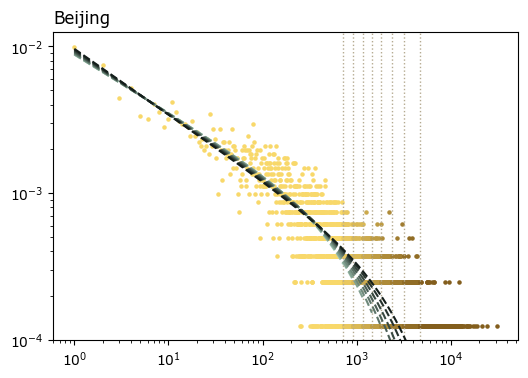

In [37]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (6, 4)

lyg_dot_clr = color_vector((248,216,106), (131,94,29), 9)
lyg_lne_clr = color_vector((164,202,182), (20,30,27), 9)


for v in range(2,10):
    plt.vlines(x=xdata[vline[v]-1], ymin=10e-5,ymax=10e-2, lw=1, ls=":",color="#b5aa90")

#plt.scatter(xdata[:c1], ydata[:c1], s= 5, color=lyg_dot_clr[0])
#plt.scatter(xdata[c1:c2], ydata[c1:c2], s= 5, color=lyg_dot_clr[1])
plt.scatter(xdata[:c3], ydata[:c3], s= 5, color=lyg_dot_clr[0])
plt.scatter(xdata[c3:c4], ydata[c3:c4], s= 5, color=lyg_dot_clr[1])
plt.scatter(xdata[c4:c5], ydata[c4:c5], s= 5, color=lyg_dot_clr[2])
plt.scatter(xdata[c5:c6], ydata[c5:c6], s= 5, color=lyg_dot_clr[3])
plt.scatter(xdata[c6:c7], ydata[c6:c7], s= 5, color=lyg_dot_clr[4])
plt.scatter(xdata[c7:c8], ydata[c7:c8], s= 5, color=lyg_dot_clr[5])
plt.scatter(xdata[c8:c9], ydata[c8:c9], s= 5, color=lyg_dot_clr[6])
plt.scatter(xdata[c9:c0], ydata[c9:c0], s= 5, color=lyg_dot_clr[7])
plt.scatter(xdata[c0:], ydata[c0:], s= 5, color=lyg_dot_clr[8])

# plt.plot(xdata[:c1], func2(xdata[:c1], *popt11), ls="--", color=lyg_lne_clr[0], label = '50%')
# plt.plot(xdata[:c2], func2(xdata[:c2], *popt22), ls="--", color=lyg_lne_clr[1], label = '45%')
plt.plot(xdata[:c3], func2(xdata[:c3], *popt33), ls="--", color=lyg_lne_clr[0], label = '40%')
plt.plot(xdata[:c4], func2(xdata[:c4], *popt44), ls="--", color=lyg_lne_clr[1], label = '35%')
plt.plot(xdata[:c5], func2(xdata[:c5], *popt55), ls="--", color=lyg_lne_clr[2], label = '30%')
plt.plot(xdata[:c6], func2(xdata[:c6], *popt66), ls="--", color=lyg_lne_clr[3], label = '25%')
plt.plot(xdata[:c7], func2(xdata[:c7], *popt77), ls="--", color=lyg_lne_clr[4], label = '20%')
plt.plot(xdata[:c8], func2(xdata[:c8], *popt88), ls="--", color=lyg_lne_clr[5], label = '15%')
plt.plot(xdata[:c9], func2(xdata[:c9], *popt99), ls="--", color=lyg_lne_clr[6], label = '10%')
plt.plot(xdata[:c0], func2(xdata[:c0], *popt00), ls="--", color=lyg_lne_clr[7], label = ' 5%')
plt.plot(xdata, func2(xdata, *popt_t), ls="--", color=lyg_lne_clr[8], label = ' 0%')

#plt.vlines(x=c8,ymin=10e-5,ymax=10e-2,lw=2, ls=":",color="#393733")

plt.title('Beijing',loc='left')
plt.xscale('log')
plt.yscale('log')
plt.ylim((10e-5,10**-1.9))
# plt.legend(loc='upper right')
plt.show()

In [10]:
sele_strength = all_strength
day_fit = []
purning = [50,45,40,35,30,25,20,15,10,5,0]
for dd in sele_strength['date'].value_counts().to_frame().index:
    day_strength = sele_strength.loc[sele_strength['date']==dd]
    s = day_strength['strength_values'].value_counts().to_frame().reset_index(drop=False).sort_values('index')
    xdata = s['index'].values
    ydata = s['strength_values'].values
    ydata = ydata/sum(ydata)
    c1 = len(np.where(np.cumsum(ydata)<0.50)[0])
    c2 = len(np.where(np.cumsum(ydata)<0.55)[0])
    c3 = len(np.where(np.cumsum(ydata)<0.60)[0])
    c4 = len(np.where(np.cumsum(ydata)<0.65)[0])
    c5 = len(np.where(np.cumsum(ydata)<0.70)[0])
    c6 = len(np.where(np.cumsum(ydata)<0.75)[0])
    c7 = len(np.where(np.cumsum(ydata)<0.80)[0])
    c8 = len(np.where(np.cumsum(ydata)<0.85)[0])
    c9 = len(np.where(np.cumsum(ydata)<0.90)[0])
    c0 = len(np.where(np.cumsum(ydata)<0.95)[0])
    vline = [c1,c2,c3,c4,c5,c6,c7,c8,c9,c0,len(ydata)]
    for v in range(2,11):
        popt, pcov = curve_fit(func2, xdata[:vline[v]], ydata[:vline[v]],p0=[0.3,60,0.01], maxfev = 5108000)

        ks_t = kstest(np.cumsum(ydata[:vline[v]]),np.cumsum(func2(xdata[:vline[v]], *popt))
        day_fit.append([dd,purning[v],popt[0],popt[1],ks_t[0],ks_t[1]])

df_fit = pd.DataFrame(day_fit)
df_fit.columns = ['Date','Pruning','Alpha','Lambda','d','p']

In [11]:
import scipy.stats

grouped_means = df_fit.groupby('Pruning')[['Alpha', 'Lambda']].mean().reset_index(drop=False)

def conf_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return m-h, m+h

Alpha_conf_interval = df_fit.groupby('Pruning')[['Alpha']].apply(conf_interval).apply(pd.Series)
Alpha_conf_interval = Alpha_conf_interval.rename(columns={0: 'Lower_Alpha', 1: 'Upper_Alpha'})
Alpha_conf_interval['Lower_Alpha'] = Alpha_conf_interval['Lower_Alpha'].apply(lambda x:x[0])
Alpha_conf_interval['Upper_Alpha'] = Alpha_conf_interval['Upper_Alpha'].apply(lambda x:x[0])
Alpha_conf_interval = Alpha_conf_interval.reset_index(drop=False)
final_df = pd.merge(grouped_means, Alpha_conf_interval, on='Pruning')

Lambda_conf_interval = df_fit.groupby('Pruning')[['Lambda']].apply(conf_interval).apply(pd.Series)
Lambda_conf_interval = Lambda_conf_interval.rename(columns={0: 'Lower_Lambda', 1: 'Upper_Lambda'})
Lambda_conf_interval['Lower_Lambda'] = Lambda_conf_interval['Lower_Lambda'].apply(lambda x:x[0])
Lambda_conf_interval['Upper_Lambda'] = Lambda_conf_interval['Upper_Lambda'].apply(lambda x:x[0])
Lambda_conf_interval = Lambda_conf_interval.reset_index(drop=False)
final_df = pd.merge(final_df, Lambda_conf_interval, on='Pruning')
final_df = final_df[final_df['Pruning']<=40]

In [12]:
final_df

,Pruning,Alpha,Lambda,Lower_Alpha,Upper_Alpha,Lower_Lambda,Upper_Lambda
0,0,0.434253,2577.796585,0.421322,0.447185,2154.976896,3000.616275
1,5,0.426800,2135.911370,0.414082,0.439517,1846.420943,2425.401797
2,10,0.417646,1743.415944,0.404652,0.430639,1535.308168,1951.523721
3,15,0.408998,1461.166013,0.395567,0.422430,1300.049886,1622.282140
4,20,0.401168,1253.846605,0.387341,0.414995,1125.995370,1381.697840
5,25,0.393748,1090.982014,0.379391,0.408106,985.425665,1196.538363
6,30,0.387826,977.543166,0.372967,0.402686,885.239691,1069.846642
7,35,0.383390,900.964894,0.367878,0.398903,813.148910,988.780879
8,40,0.380651,853.553170,0.364704,0.396598,769.783551,937.322789


In [ ]:
(977.543166-2577.796585)/2577.796585

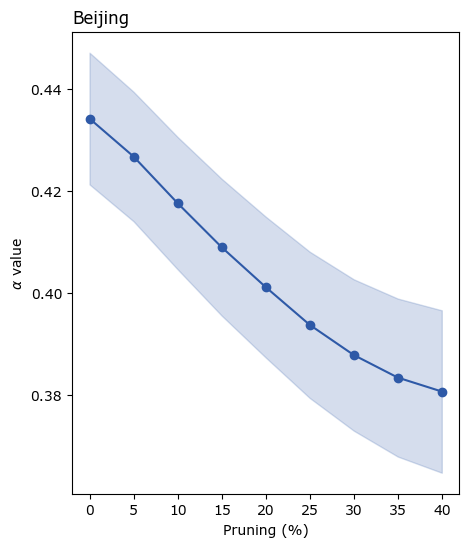

In [15]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (5, 6)

alpha_clr = "#{:02x}{:02x}{:02x}".format(46, 89, 167)
lambda_clr = "#{:02x}{:02x}{:02x}".format(176, 69, 82)

plt.plot(final_df['Pruning'], final_df['Alpha'], marker='o', linestyle='-', color=alpha_clr)

alpha_lower_ci = final_df['Lower_Alpha']
alpha_upper_ci = final_df['Upper_Alpha']

plt.fill_between(final_df['Pruning'], alpha_lower_ci, alpha_upper_ci, color=alpha_clr, alpha=0.2)

plt.title('Beijing',loc='left')
plt.xlabel('Pruning (%)')
plt.ylabel(r'$\alpha$ value')
plt.xticks(final_df['Pruning'][::1])
plt.show()

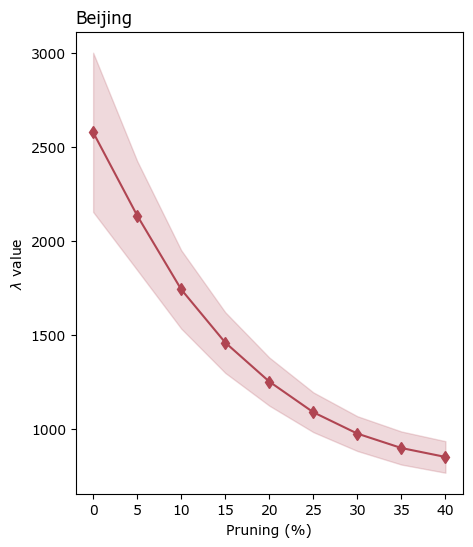

In [14]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (5, 6)

alpha_clr = "#{:02x}{:02x}{:02x}".format(46, 89, 167)
lambda_clr = "#{:02x}{:02x}{:02x}".format(176, 69, 82)

plt.plot(final_df['Pruning'], final_df['Lambda'], marker='d', color=lambda_clr)

alpha_lower_ci = final_df['Lower_Lambda']
alpha_upper_ci = final_df['Upper_Lambda']

plt.fill_between(final_df['Pruning'], alpha_lower_ci, alpha_upper_ci, color=lambda_clr, alpha=0.2)

plt.title('Beijing',loc='left')
plt.xlabel('Pruning (%)')
plt.ylabel(r'$\lambda$ value')
plt.xticks(final_df['Pruning'][::1])
plt.show()

In [ ]:
s_date = dtm.datetime.strptime('20191202','%Y%m%d')
e_date = dtm.datetime.strptime('20191216','%Y%m%d')
strength = all_strength[(all_strength['date'] >= s_date ) & (all_strength['date'] < e_date)]
strength['date'] = strength['date'].apply(lambda x: dtm.datetime.strftime(x,'%m-%d'))

In [ ]:

strength = pd.pivot(strength,index='hex_id',columns='date',values='strength_values')
stre_coor = strength.corr()

In [ ]:
import scipy.stats as st
coor_flat = np.zeros(int((len(stre_coor)-1)*len(stre_coor)/2))
m=0
for i in range(len(stre_coor)):
  for j in range(len(stre_coor)):
    if i < j:
      coor_flat[m]=stre_coor.iloc[i,j]
      m=m+1

print(np.mean(coor_flat))
ci = st.t.interval(confidence=0.95, df=len(coor_flat)-1,
              loc=np.mean(coor_flat),
              scale=st.sem(coor_flat))

(ci[1]-ci[0])/2

In [ ]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
f, ax = plt.subplots(figsize=(20, 16)) 
mask = np.zeros_like(stre_coor)

for i in range(1,len(mask)):

  for j in range(0,i):

    mask[j][i] = True# 掩盖掉上面的三角形

sns.heatmap(stre_coor, annot=False,mask=mask,cmap="OrRd",linewidths= 5,square=True)

plt.subplots_adjust(left=.1, right=0.95, bottom=0.22, top=0.95)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
plt.xlabel('')
plt.ylabel('')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()#显示绘图内容

In [ ]:
col = 0

date_stre = strength.iloc[:,col].to_frame().fillna(0)
index_stre = strength.index

In [ ]:

spaceMatrix = pd.DataFrame({},index=strength.index,columns=strength.index)
for province1 in spaceMatrix.index:
    for province2 in spaceMatrix.columns:
        if not np.isnan(spaceMatrix.loc[province1,province2]):
            continue
        #两地距离
        try:
            distance = h3.point_dist(h3.h3_to_geo(province1),h3.h3_to_geo(province2),'km')
            spaceMatrix.loc[province1,province2] = distance
            spaceMatrix.loc[province2,province1] = distance
        except:
            spaceMatrix.loc[province1,province2] = np.nan
            spaceMatrix.loc[province2,province1] = np.nan
            continue
        #地点相同，距离取无穷大，不然后面的倒数会报错
        if province1==province2:
            spaceMatrix.loc[province1,province2] = 10e17
spaceMatrix = spaceMatrix**-3

In [ ]:
moran = pd.DataFrame({},index=strength.columns,columns=['I','ZI_N'])
for col in range(len(strength.columns)):
    date_stre = strength.iloc[:,col].to_frame().fillna(0)
    result = moranI(spaceMatrix,date_stre)
    moran.loc[strength.columns[col],'I']=np.round(result['I']['value'],3)
    moran.loc[strength.columns[col],'ZI_N']=np.round(result['ZI_N']['value'],3)

In [ ]:
moran

In [ ]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
f, ax = plt.subplots(figsize=(8, 6)) 
plt.subplots_adjust(left=.1, right=0.95, bottom=0.22, top=0.95)

sns.scatterplot(x=moran.index,y=moran.I)
plt.xlabel('Date')
plt.ylabel('Moran\'s I')
plt.xticks(fontsize=10,rotation=90)
plt.yticks(fontsize=10)
plt.ylim(0.24,0.5)
plt.show()#显示绘图内容

In [ ]:
from statsmodels.tsa.stattools import adfuller
tem_result = adfuller(moran.I.values)

In [ ]:
alpha = 0.05
if tem_result[1] < alpha:  # p_value值大，无法拒接原假设,有可能单位根，需要T检验
    print("stationarity")
else:
    if tem_result[0] < tem_result[4]['5%']:  # 代表t检验的值小于5%,置信度为95%以上，这里还有'1%'和'10%'
        print("stationarity")  # 拒接原假设，无单位根，平稳的
    else:
        print("no_stationarity")

In [ ]:
tem_result

In [ ]:
from minepy import pstats, cstats
from cmcrameri import cm

sele_strength = all_strength
fluc = sele_strength.groupby(['date']).agg({'strength_values':'describe'})
date_list = pd.date_range(start=fluc.index.min(),end=fluc.index.max(),freq='D')
hexagon = pd.crosstab(
    index=sele_strength['date'],
    columns=all_strength['hex_id'],
    values=all_strength['strength_values'],
    aggfunc='sum').reindex(index=date_list).fillna(0)
hexagon_data = np.array(hexagon)

mic_c, tic_c = cstats(hexagon_data.T,hexagon_data.T,alpha=9,c=15,est="mic_e")
mic = pd.DataFrame(data=mic_c,index=hexagon.columns.values,columns=hexagon.columns.values)


In [ ]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.family']=['Verdana']
ax = sns.clustermap(
    data=mic, vmin=0, vmax=1, cmap=cm.lajolla, linecolor='#f1f1f1',
    method = 'ward', metric='euclidean',
    xticklabels=False, yticklabels=False)
ax.cax.set_position([1,0,0.05,0.8])
ax.cax.tick_params(labelsize=20)
plt.show()


In [ ]:
import scipy.cluster.hierarchy as sch
colors_hex = ['#1F77B3', '#FF7F0E', '#2CA02C', '#D62728',
              '#9467BD', '#8C564B', '#E377C2', '#7F7F7F']
plt.figure(dpi=600,figsize=(8.5,3))

plt.rcParams['font.sans-serif'] = ['Verdana']
sch.set_link_color_palette(colors_hex)
thd = 232

#plt.axhline(y=thd,lw=1,ls="--",c="#393733")#添加水平直线
dendrogram = sch.dendrogram(
    sch.linkage(mic, method = 'ward',metric='euclidean'),
    labels=mic.index,above_threshold_color='#bbb5ac')

plt.xticks([])
plt.show()


In [1]:
from h3 import h3
import folium
import folium.plugins

attr_anno = 'Map tiles by &copy; <a href="https://carto.com/attributions">CARTO</a>, under <a href="http://creativecommons.org/licenses/by/3.0">CC BY 3.0</a>. Data by &copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a>, under <a href="https://creativecommons.org/licenses/by-sa/3.0/">CC-BY-SA</a>.'
map_tile = 'https://{s}.basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}{r}.png'
cen_loc = [34.6412,119.234865]

In [ ]:
clustering = pd.DataFrame({
    "hexagon_id": dendrogram['ivl'],
    "category": dendrogram['leaves_color_list']
    })
clustering['Polygon'] = clustering['hexagon_id'].apply(lambda x: h3.h3_to_geo_boundary(x))


In [ ]:
city_map = folium.Map(
    location = cen_loc,
    zoom_start = 11,
    max_zoom = 16,
    min_zoom = 8,
    no_touch = True,
    zoom_control = False,
    control_scale = True,
    prefer_canvas = True,
    attr = attr_anno,
    tiles = map_tile,
)

#H3
H3_map = folium.map.FeatureGroup()
for row_index, row_data in clustering.iterrows():
    H3_map.add_child(
        folium.Polygon(
            row_data['Polygon'],
            color = row_data['category'],
            fill_color = row_data['category'],
            fill_opacity = 0.8,
            opacity = 0.2,
            fill = True
        )
    )
    
city_map.add_child(H3_map)

# 添加图例

# 显示地图
map_name = 'BJCLUSTER.html'
map_path = os.path.join(work_path,map_name)
city_map.save(map_path)

In [4]:
city_map = folium.Map(
    location = cen_loc,
    zoom_start = 11,
    max_zoom = 16,
    min_zoom = 8,
    no_touch = True,
    zoom_control = False,
    control_scale = True,
    prefer_canvas = True,
    attr = attr_anno,
    tiles = map_tile,
)
city_map.save('nothingmap.html')